In [8]:
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import random
import scanpy as sc
import seaborn as sns
import os
import sys

main_path = os.getcwd()
sys.path.append(main_path)

In [9]:
panel_name = 'latticea-hallmarks'
adata_path = os.path.join(main_path, 'data', 'ssl_adata', panel_name)

ssl_hallmarks_train = ad.read_h5ad(os.path.join(adata_path, 'adata-train.hdf5'))
ssl_hallmarks_valid = ad.read_h5ad(os.path.join(adata_path, 'adata-valid.hdf5'))
ssl_hallmarks_train.obs['samples'] = ssl_hallmarks_train.obs['sample_id'].apply(lambda x: x[:8])
ssl_hallmarks_valid.obs['samples'] = ssl_hallmarks_valid.obs['sample_id'].apply(lambda x: x[:8])

ssl_hallmarks_train.obs.rename(columns={'sample_id':'core'}, inplace=True)
ssl_hallmarks_valid.obs.rename(columns={'sample_id':'core'}, inplace=True)

ssl_hallmarks_train.obs['original_set'] = 'train'
ssl_hallmarks_valid.obs['original_set'] = 'valid'

In [10]:
panel_name = 'latticea-io'
adata_path = os.path.join(main_path, 'data', 'ssl_adata', panel_name)

ssl_bioclavis_train = ad.read_h5ad(os.path.join(adata_path, 'adata-train.hdf5'))
ssl_bioclavis_valid = ad.read_h5ad(os.path.join(adata_path, 'adata-valid.hdf5'))

ssl_bioclavis_train.obs['samples'] = ssl_bioclavis_train.obs['sample_id'].apply(lambda x: x[:8])
ssl_bioclavis_valid.obs['samples'] = ssl_bioclavis_valid.obs['sample_id'].apply(lambda x: x[:8])

ssl_bioclavis_train.obs.rename(columns={'sample_id':'core'}, inplace=True)
ssl_bioclavis_valid.obs.rename(columns={'sample_id':'core'}, inplace=True)

ssl_bioclavis_train.obs['original_set'] = 'train'
ssl_bioclavis_valid.obs['original_set'] = 'valid'

In [11]:
ssl_hallmarks_train_obs = ssl_hallmarks_train.obs.copy(deep=True)
ssl_hallmarks_valid_obs = ssl_hallmarks_valid.obs.copy(deep=True)

ssl_hallmarks_all = pd.concat([ssl_hallmarks_train_obs, ssl_hallmarks_valid_obs])

ssl_bioclavis_train_obs = ssl_bioclavis_train.obs.copy(deep=True)
ssl_bioclavis_valid_obs = ssl_bioclavis_valid.obs.copy(deep=True)

ssl_bioclavis_all = pd.concat([ssl_bioclavis_train_obs, ssl_bioclavis_valid_obs])

### Cluster frequency

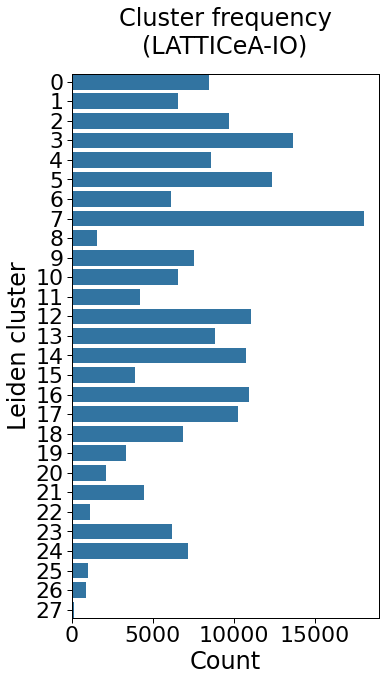

In [ ]:
sns.set_context("paper", font_scale=2.5)
mpl.rcParams['pdf.fonttype']=42

fig, ax = plt.subplots(figsize=(5.5,10))

sns.countplot(ssl_bioclavis_all, y='leiden', color='tab:blue', ax=ax)
ax.set_xlabel('Count')
ax.set_ylabel('Leiden cluster')
ax.set_title('Cluster frequency\n(LATTICeA-IO)', pad=20)
ax.margins(y=0)

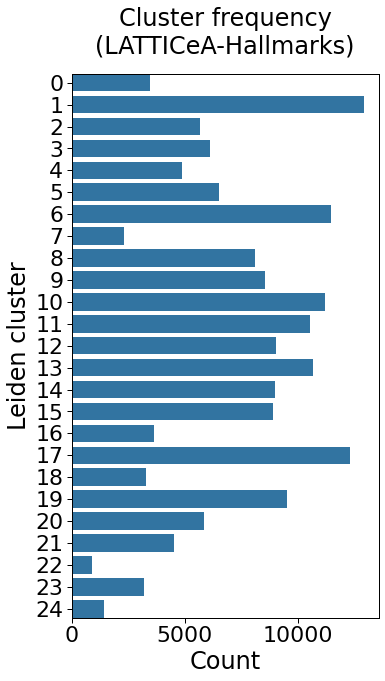

In [ ]:
fig, ax = plt.subplots(figsize=(5.5,10))

sns.countplot(ssl_hallmarks_all, y='leiden', color='tab:blue', ax=ax)
ax.set_xlabel('Count')
ax.set_ylabel('Leiden cluster')
ax.set_title('Cluster frequency\n(LATTICeA-Hallmarks)', pad=20)
ax.margins(y=0)


### Patient specificity

In [14]:
ssl_hallmarks_train_obs

,leiden,patch_path,core,samples,original_set
0,6,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_1105_23-02-I,ACA_1105,train
1,6,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_1105_23-02-I,ACA_1105,train
2,7,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_1105_23-02-I,ACA_1105,train
3,6,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_1105_23-02-I,ACA_1105,train
4,6,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_1105_23-02-I,ACA_1105,train
...,...,...,...,...,...
88676,6,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_0933_19-06-H,ACA_0933,train
88677,19,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_0933_19-06-H,ACA_0933,train
88678,6,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_0933_19-06-H,ACA_0933,train
88679,2,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_0933_19-06-H,ACA_0933,train


In [15]:
hallmarks_max_patient_contributions = list()

for cluster in ssl_hallmarks_train_obs['leiden'].dropna().unique():
    cluster_subset = ssl_hallmarks_train_obs[ssl_hallmarks_train_obs['leiden'] == cluster]
    cluster_size = len(cluster_subset)
    patients, counts = np.unique(cluster_subset['samples'].values, return_counts=True)
    counts_props = counts / cluster_size
    max_idx = np.argmax(counts_props)
    max_val = counts_props[max_idx]
    hallmarks_max_patient_contributions.append((int(cluster), max_val * 100))


In [16]:
hallmarks_max_patient_df = pd.DataFrame(hallmarks_max_patient_contributions, columns=['Cluster', 'max_perc'])
hallmarks_max_patient_df = hallmarks_max_patient_df.sort_values(by='Cluster')

Text(0.5, 1.0, 'Patient specificity (LATTICeA-Hallmarks)')

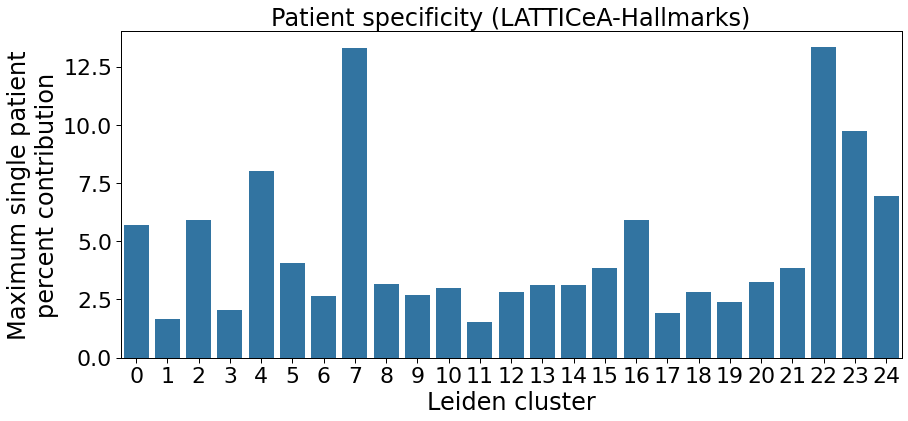

In [ ]:
fig, ax = plt.subplots(figsize=(14,6))

sns.barplot(hallmarks_max_patient_df, x = 'Cluster', y = 'max_perc', ax=ax)
ax.set_ylabel('Maximum single patient\npercent contribution')
ax.set_xlabel('Leiden cluster')
ax.set_title('Patient specificity (LATTICeA-Hallmarks)')

In [18]:
hallmarks_max_patient_df

,Cluster,max_perc
17,0,5.708938
15,1,1.666929
11,2,5.890364
3,3,2.061529
21,4,8.026208
10,5,4.054445
0,6,2.641442
1,7,13.276398
4,8,3.148104
13,9,2.688889


Text(0.5, 1.0, 'Patient specificity\n(LATTICeA-Hallmarks)')

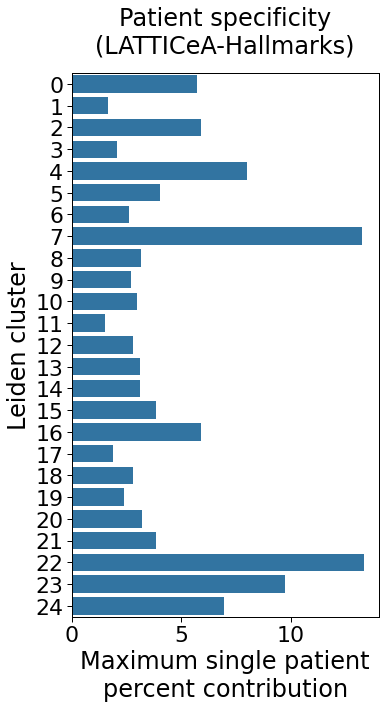

In [19]:
fig, ax = plt.subplots(figsize=(5.5,10))

sns.barplot(hallmarks_max_patient_df, x = 'max_perc', y = 'Cluster', orient='h', ax=ax)
ax.set_xlabel('Maximum single patient\npercent contribution')
ax.set_ylabel('Leiden cluster')
ax.set_title('Patient specificity\n(LATTICeA-Hallmarks)', pad=20)

In [20]:
ssl_bioclavis_train_obs

,leiden,patch_path,core,samples,original_set
0,0,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_1105_23-02-I,ACA_1105,train
1,0,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_1105_23-02-I,ACA_1105,train
2,12,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_1105_23-02-I,ACA_1105,train
3,3,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_1105_23-02-I,ACA_1105,train
4,7,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_1105_23-02-I,ACA_1105,train
...,...,...,...,...,...
98496,7,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_0933_19-06-H,ACA_0933,train
98497,1,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_0933_19-06-H,ACA_0933,train
98498,7,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_0933_19-06-H,ACA_0933,train
98499,12,b'/nfs/home/users/lfarndal/sharedscratch/datas...,ACA_0933_19-06-H,ACA_0933,train


In [21]:
bioclavis_max_patient_contributions = list()

for cluster in ssl_bioclavis_train_obs['leiden'].dropna().unique():
    cluster_subset = ssl_bioclavis_train_obs[ssl_bioclavis_train_obs['leiden'] == cluster]
    cluster_size = len(cluster_subset)
    patients, counts = np.unique(cluster_subset['samples'].values, return_counts=True)
    counts_props = counts / cluster_size
    max_idx = np.argmax(counts_props)
    max_val = counts_props[max_idx]
    bioclavis_max_patient_contributions.append((int(cluster), max_val * 100))


In [23]:
bioclavis_max_patients_df = pd.DataFrame(bioclavis_max_patient_contributions, columns=['Cluster', 'max_perc'])
bioclavis_max_patients_df = bioclavis_max_patients_df.sort_values(by='Cluster')

Text(0.5, 1.0, 'Patient specificity\n(LATTICeA-IO)')

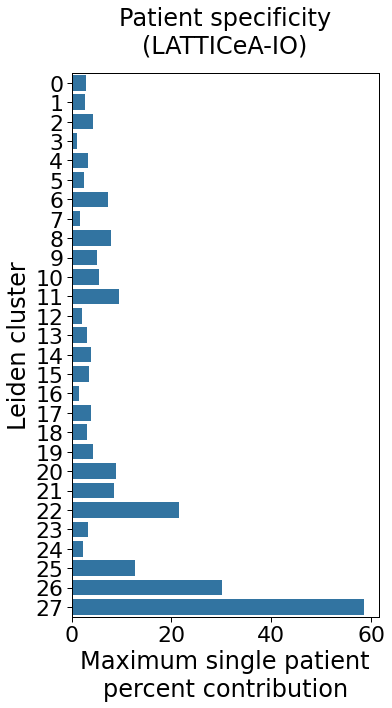

In [ ]:
fig, ax = plt.subplots(figsize=(5.5,10))

sns.barplot(bioclavis_max_patients_df, x = 'max_perc', y = 'Cluster', orient='h', ax=ax)
ax.set_xlabel('Maximum single patient\npercent contribution')
ax.set_ylabel('Leiden cluster')
ax.set_title('Patient specificity\n(LATTICeA-IO)', pad=20)

### TMA specificity

In [25]:
def split_tma_num(x):
    core = x.split('_')[-1]
    tma_num = core.split('-')[0]
    return tma_num

ssl_bioclavis_train_obs['tma'] = ssl_bioclavis_train_obs['core'].apply(lambda x: split_tma_num(x))
ssl_hallmarks_train_obs['tma'] = ssl_hallmarks_train_obs['core'].apply(lambda x: split_tma_num(x))

In [26]:
hallmarks_max_tma_contributions = list()

for cluster in ssl_hallmarks_train_obs['leiden'].dropna().unique():
    cluster_subset = ssl_hallmarks_train_obs[ssl_hallmarks_train_obs['leiden'] == cluster]
    cluster_size = len(cluster_subset)
    patients, counts = np.unique(cluster_subset['tma'].values, return_counts=True)
    counts_props = counts / cluster_size
    max_idx = np.argmax(counts_props)
    max_val = counts_props[max_idx]
    hallmarks_max_tma_contributions.append((int(cluster), max_val * 100))


In [27]:
hallmarks_max_tma_df = pd.DataFrame(hallmarks_max_tma_contributions, columns=['Cluster', 'max_perc'])
hallmarks_max_tma_df = hallmarks_max_tma_df.sort_values(by='Cluster')

Text(0.5, 1.0, 'Slide specificity\n(LATTICeA-Hallmarks)')

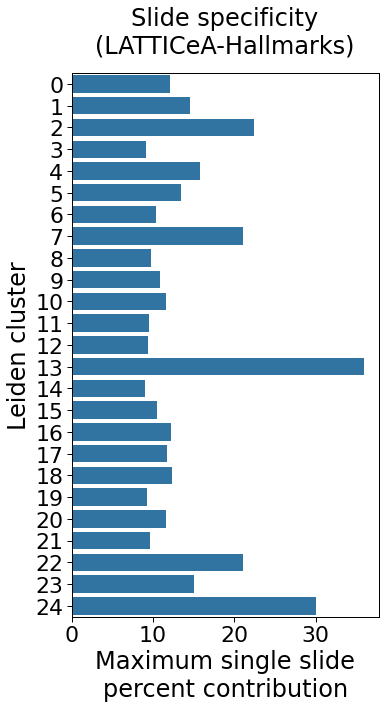

In [ ]:
fig, ax = plt.subplots(figsize=(5.5,10))

sns.barplot(hallmarks_max_tma_df, x = 'max_perc', y = 'Cluster', orient='h', ax=ax)
ax.set_xlabel('Maximum single slide\npercent contribution')
ax.set_ylabel('Leiden cluster')
ax.set_title('Slide specificity\n(LATTICeA-Hallmarks)', pad=20)

In [29]:
bioclavis_max_tma_contributions = list()

for cluster in ssl_bioclavis_train_obs['leiden'].dropna().unique():
    cluster_subset = ssl_bioclavis_train_obs[ssl_bioclavis_train_obs['leiden'] == cluster]
    cluster_size = len(cluster_subset)
    patients, counts = np.unique(cluster_subset['tma'].values, return_counts=True)
    counts_props = counts / cluster_size
    max_idx = np.argmax(counts_props)
    max_val = counts_props[max_idx]
    bioclavis_max_tma_contributions.append((int(cluster), max_val * 100))


In [30]:
bioclavis_max_tma_df = pd.DataFrame(bioclavis_max_tma_contributions, columns=['Cluster', 'max_perc'])
bioclavis_max_tma_df = bioclavis_max_tma_df.sort_values(by='Cluster')

Text(0.5, 1.0, 'Slide specificity\n(LATTICeA-IO)')

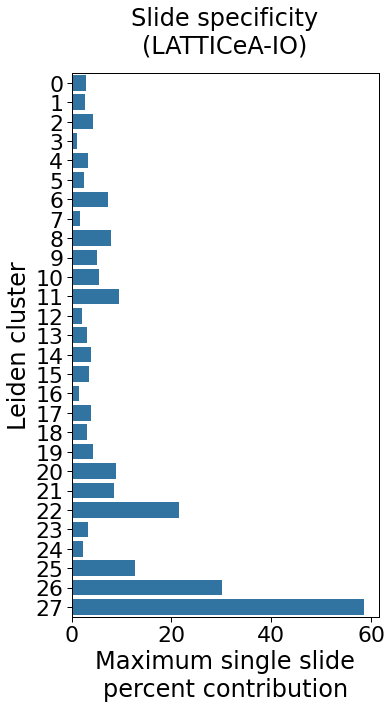

In [31]:
fig, ax = plt.subplots(figsize=(5.5,10))

sns.barplot(bioclavis_max_patients_df, x = 'max_perc', y = 'Cluster', orient='h', ax=ax)
ax.set_xlabel('Maximum single slide\npercent contribution')
ax.set_ylabel('Leiden cluster')
ax.set_title('Slide specificity\n(LATTICeA-IO)', pad=20)